# Hierarchal Clustering Implementation(Agglomerative Clustering)

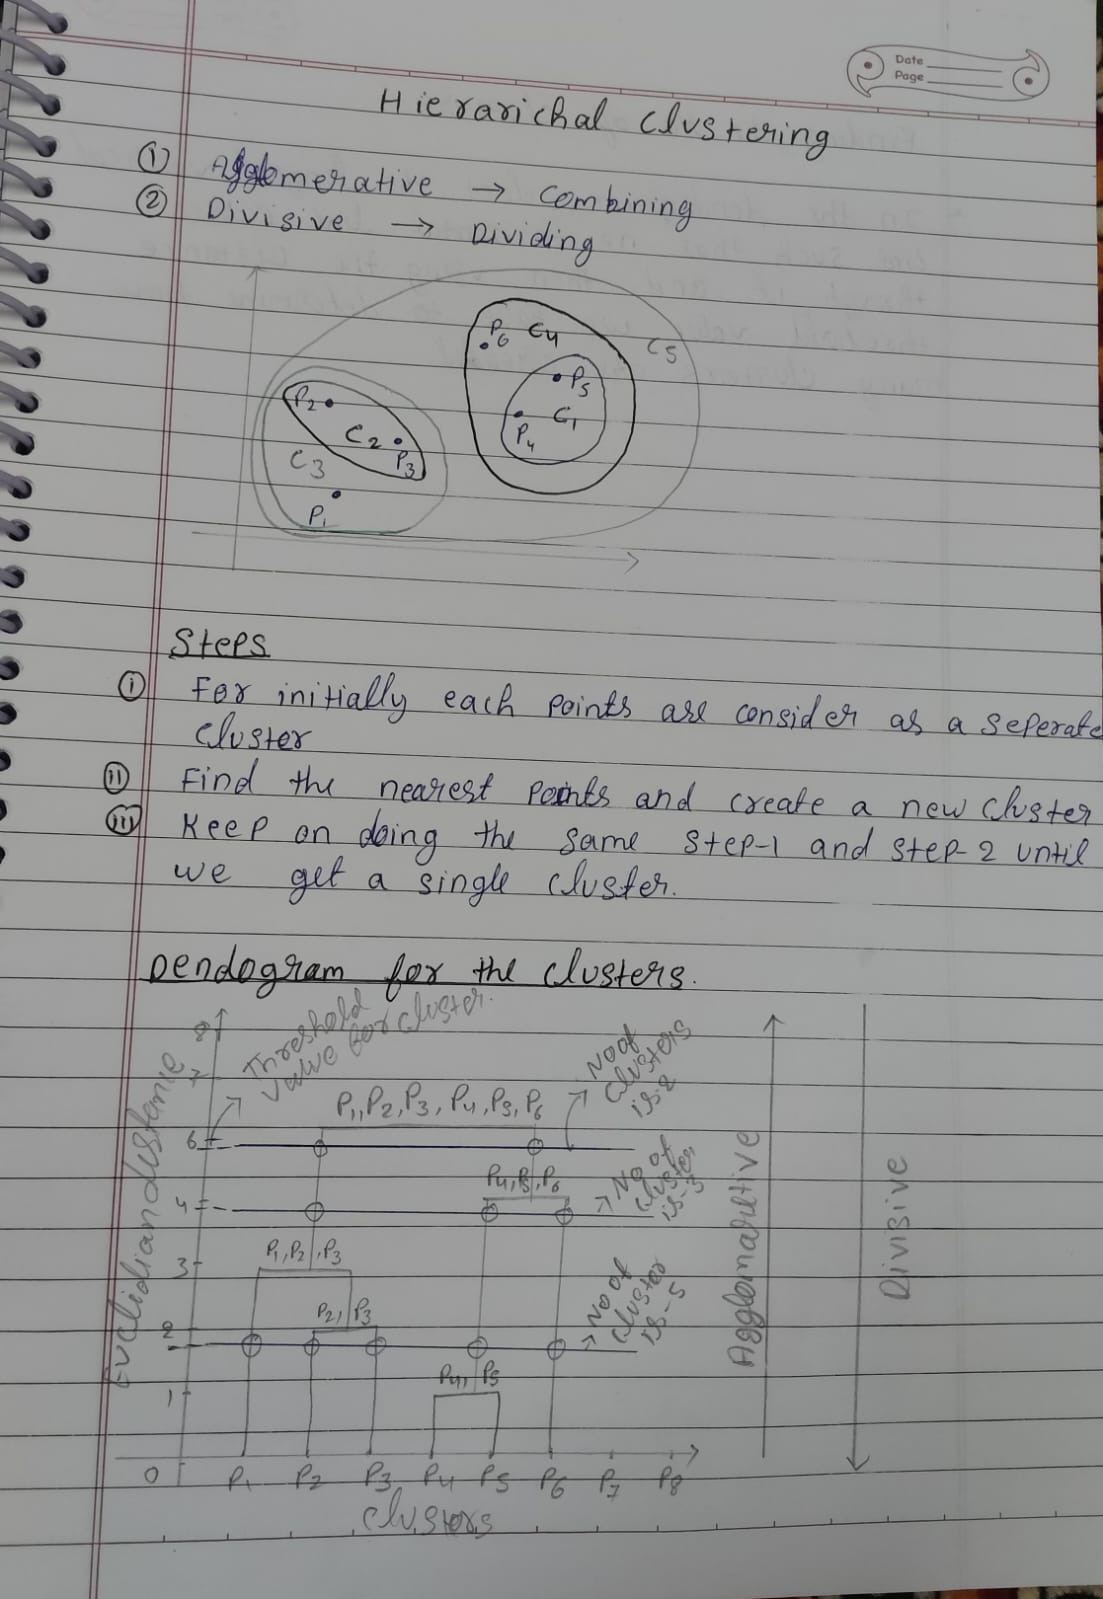

In [1]:
from IPython.display import Image, display
display(Image(filename='theory.jpg'))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn import datasets

In [4]:
iris = datasets.load_iris()
iris_data = pd.DataFrame(iris.data)

In [6]:
iris_data.columns = iris.feature_names

In [8]:
iris_data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_scaled = scalar.fit_transform(iris_data)

## Apply PCA

In [12]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

In [13]:
pca_scaled = pca.fit_transform(X_scaled)

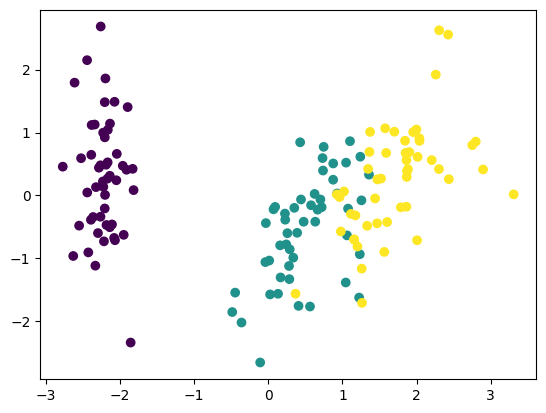

In [15]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1], c = iris.target)

## Agglomerative Clustering

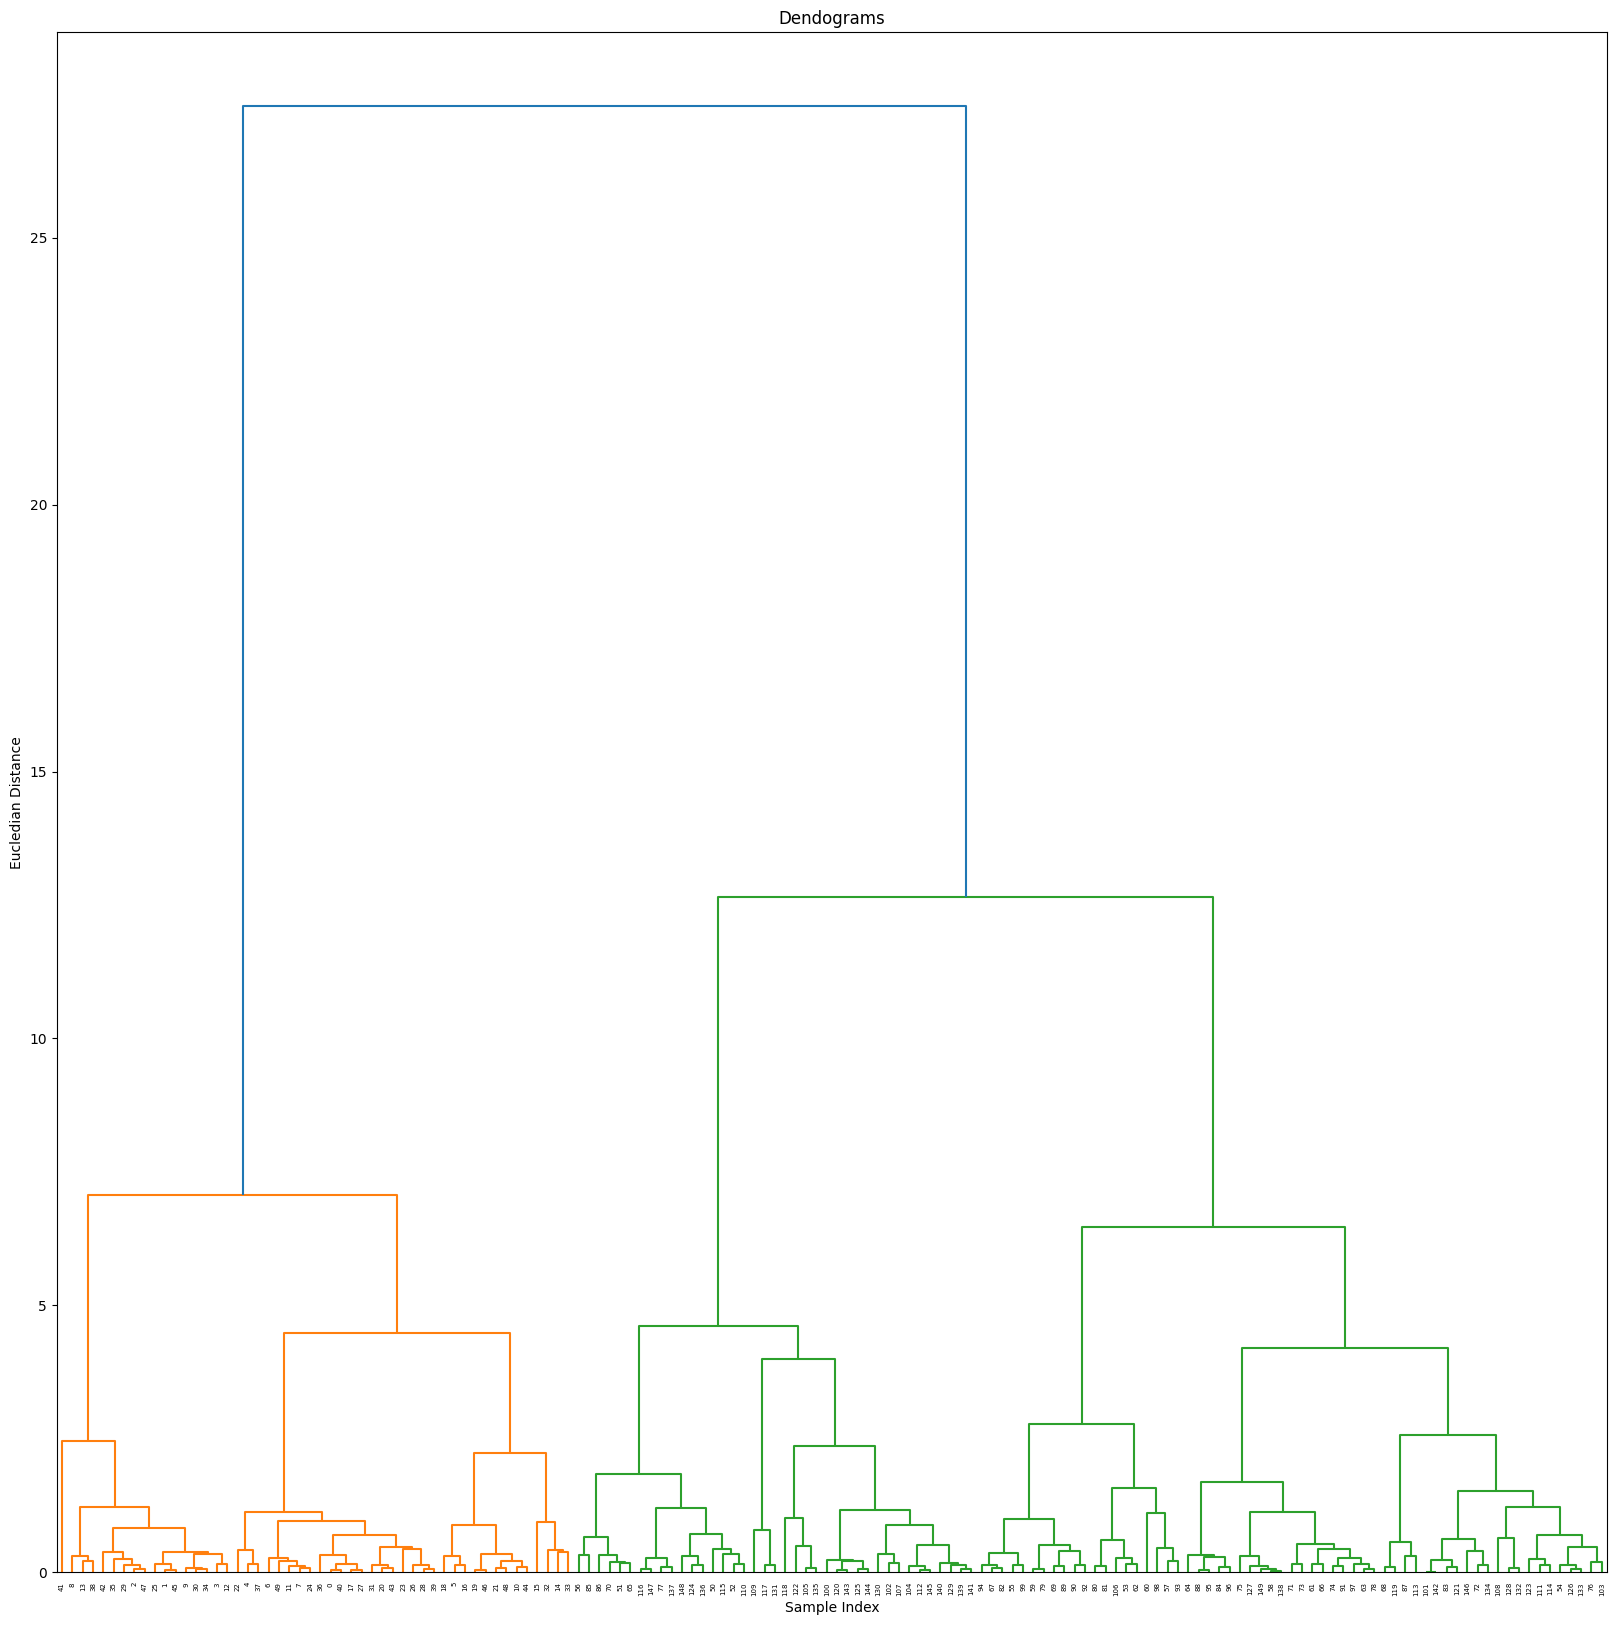

In [18]:
## Constructive a dendogram
import scipy.cluster.hierarchy as sc

plt.figure(figsize=(20,20))
plt.title("Dendograms")
sc.dendrogram(sc.linkage(pca_scaled, method='ward'))
plt.xlabel("Sample Index")
plt.ylabel('Eucledian Distance')
plt.show()

In [20]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=2, linkage='ward')
cluster.fit(pca_scaled)

AgglomerativeClustering()

In [21]:
cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

### Final Clusters

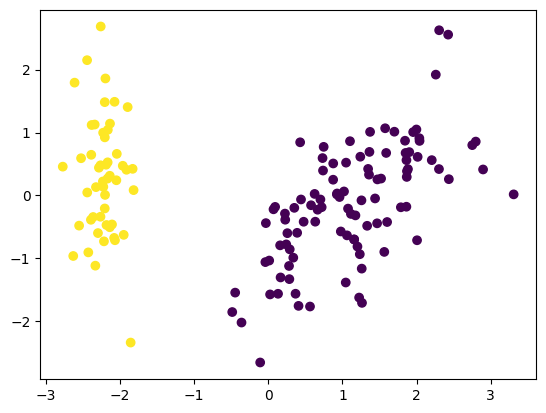

In [23]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1], c = cluster.labels_)